# Handwritten Digit Recognition - CNN Training
This notebook trains a CNN on the MNIST dataset and saves the model.

In [11]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
# Load the MNIST dataset (60,000 training images, 10,000 test images)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f'Training samples: {x_train.shape[0]}')
print(f'Test samples:     {x_test.shape[0]}')
print(f'Image shape:      {x_train.shape[1:]}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step
Training samples: 60000
Test samples:     10000
Image shape:      (28, 28)


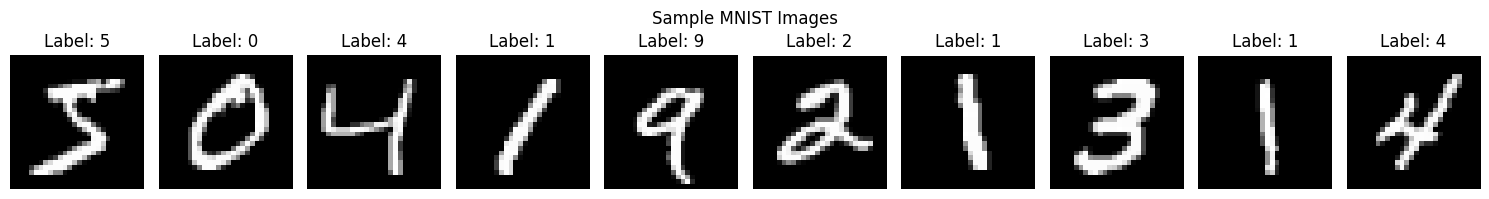

In [3]:
# Preview a few sample images from the dataset
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values from 0-255 to 0-1
# This helps the model learn faster and more accurately
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Reshape to (samples, height, width, channels)
# CNN expects a 4D input; MNIST is grayscale so channels=1
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f'x_train shape: {x_train.shape}')
print(f'x_test shape:  {x_test.shape}')

x_train shape: (60000, 28, 28, 1)
x_test shape:  (10000, 28, 28, 1)


In [5]:
# Build the CNN model
model = models.Sequential([
    # First convolutional block
    # Conv2D learns 32 filters of size 3x3 to detect edges and patterns
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # MaxPooling reduces spatial size by taking the max in each 2x2 region
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block — learns more complex features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten converts 2D feature maps into a 1D vector
    layers.Flatten(),

    # Dropout randomly disables 50% of neurons during training to prevent overfitting
    layers.Dropout(0.5),

    # Dense layer with 128 neurons for high-level reasoning
    layers.Dense(128, activation='relu'),

    # Output layer: 10 neurons (one per digit 0-9), softmax gives probabilities
    layers.Dense(10, activation='softmax')
])

model.summary()

D:\clg\MP 2\Handwritten-Digit-Recognizer\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the model
# adam     - adaptive optimizer, works well out of the box
# loss     - sparse_categorical_crossentropy is used when labels are integers (not one-hot)
# metrics  - track accuracy during training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# Train the model for 10 epochs
# validation_split=0.1 uses 10% of training data to monitor validation accuracy
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.9355 - loss: 0.2073 - val_accuracy: 0.9843 - val_loss: 0.0514
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9764 - loss: 0.0754 - val_accuracy: 0.9893 - val_loss: 0.0379
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9819 - loss: 0.0573 - val_accuracy: 0.9895 - val_loss: 0.0355
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9846 - loss: 0.0474 - val_accuracy: 0.9890 - val_loss: 0.0321
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.9872 - loss: 0.0401 - val_accuracy: 0.9907 - val_loss: 0.0353
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.9894 - loss: 0.0329 - val_accuracy: 0.9923 - val_loss: 0.0293
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9897 - loss: 0.0321 - val_accuracy: 0.9922 - val_loss: 0.0304
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9910 - loss: 0.0287 - 

In [8]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc * 100:.2f}%')
print(f'Test Loss:     {test_loss:.4f}')

Test Accuracy: 99.11%
Test Loss:     0.0267


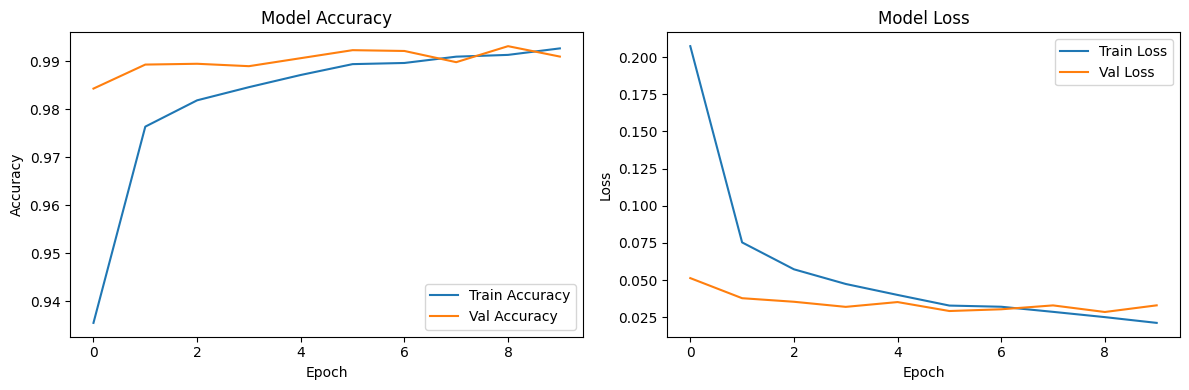

In [9]:
# Plot training & validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
# Save the trained model to disk
# This file will be loaded by the Streamlit app for predictions
model.save('mnist_cnn.h5')
print('Model saved as mnist_cnn.h5')

Model saved as mnist_cnn.h5


In [12]:
x = mnist.load_data()

In [15]:
imshow(x_train[1], cmap='gray')

NameError: name 'imshow' is not defined